# ANÁLISE DOS INIMIGOS DO RESIDENT EVIL

- **Objetivo 1:** Identificar os inimigos que aparecem em mais jogos diferentes.

- **Objetivo 2:** Identificar qual o jogo com maior diversidade de inimigos.

- **Objetivo 3:** Identificar Qual agente biológico é responsável pela maior variedade de inimigos.


### Ferramentas Utilizadas:

- **`Python 3.x`**

- **`Matplotlib`:** Visualização e criação de gráficos customizados.

- **`Pandas`:** Manipulação e tratamento de dados.


### Jogos Separados:
Os jogos utilizados para essa análise foram os:
- Resident evil 0
- Resident evil 1
- Resident evil 2 remake
- Resident evil 3 remake
- Resident evil outbreak 1
- Resident evil outbreak 2
- Resident evil the umbrella chronicles
- Resident evil the darkside chronicles
- Resident evil outbreak 2
- Resident evil code veronica
- Resident evil 4 remake
- Resident evil survivor
- Resident evil dead aim
- Resident evil 5
- Resident evil 6
- Resident evil 7
- Resident evil village

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


### Aqui Começa o tratamento dos dados e preparação para a criação do primeiro gráfico:

- Li o arquivo csv, definindo o separador como a '|'.

- Tratei as colunas para o Python entender ela melhor.

- Criei a coluna 'Total_Jogos', que vai ser responsável por exibir a quantidade de jogos que o monstro já apareceu.

- Ajustei a coluna das Criaturas para ficar com a primeira letra maiúscula.

- Organizei para ordenar pela coluna 'Total_jogos' exibindo do maior para o menor, e pegar os 5 primeiros.

In [ ]:
dados = pd.read_csv("dataset-monstros.csv", sep="|")

dados.columns = dados.columns.str.replace('"', '').str.strip()

dados['Total_Jogos'] = dados['Jogos'].str.split(',').str.len()

dados['Criaturas'] = dados['Criaturas'].str.capitalize()

dados_jogos = dados.sort_values('Total_Jogos', ascending=False).iloc[:5]


dados_jogos.head()

,Criaturas,Componentes,Jogos,Total_Jogos
0,Zumbi,t-virus,"Resident evil 0,Resident evil 1,Resident evil...",12
1,Cerberus,t-virus,"Resident evil 0,Resident evil 1,Resident evil...",10
4,Crow,t-virus,"Resident evil 0,Resident evil 1,Resident evil...",7
8,Hunter alpha,"t-virus,dna de reptil em ovulos humanos","Resident evil 0,Resident evil 1,Resident evil...",7
25,Licker,t-virus,"Resident evil 2,Resident evil 3,Resident evil...",7


## Análise de Recorrência de Inimigos
Este gráfico tem como objetivo exibir os 5 inimigos mais comuns da franquia, ou seja, aqueles que aparecem em mais jogos diferentes. Como esperado, o grande destaque são os **Zumbis convencionais**, seguidos pelos **Cerberus** (os icônicos cães infectados). Logo em sequência, nota-se um empate técnico entre o **Crow**, o **Hunter Alpha** e o **Licker**.

A visualização reforça que, apesar da evolução da série, as criaturas clássicas permanecem como a verdadeira marca registrada de Resident Evil.

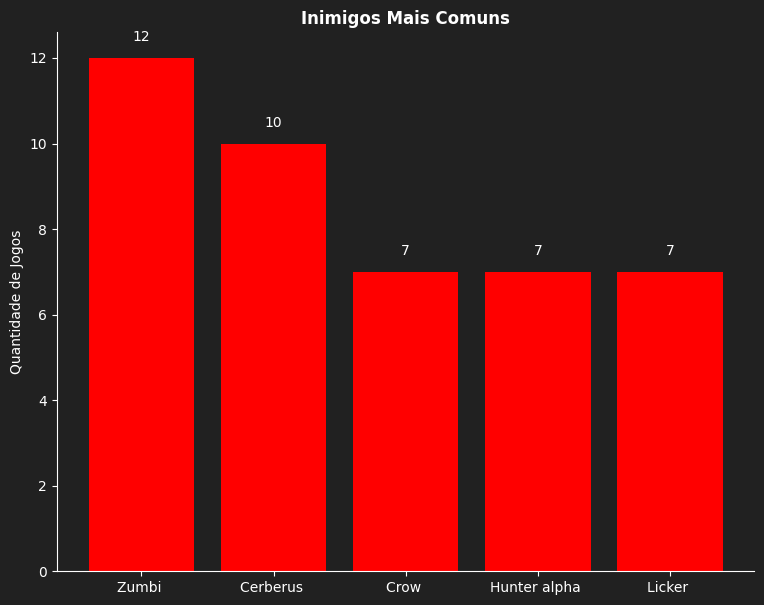

In [3]:
fig, ax = plt.subplots( figsize=(9, 7))

barras = ax.bar(
    dados_jogos['Criaturas'],
    dados_jogos['Total_Jogos'],
    color='red'
)

ax.bar_label(barras, color='white', padding=10)

ax.set_title("Inimigos Mais Comuns", color='white', weight='bold')
ax.set_ylabel('Quantidade de Jogos', color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

fig.set_facecolor('#212121')
ax.set_facecolor('#212121')




## Preparando para a criação do segundo gráfico.

- Fiz uma copia do dataset 'dados' criado anteriormente

- usei o split() para poder separar por virgula, criando a lista de jogos

- usei o explode para separar os monstros por jogos, e depois usei o vacue counts no 'contagem_jogos' para unir novamente e contar as aparições. 


In [4]:
df_analise = dados.copy()

df_analise['Jogos'] = df_analise['Jogos'].str.split(',')

df_analise = df_analise.explode('Jogos')

df_analise['Jogos'] = df_analise['Jogos'].str.strip()

contagem_jogos = df_analise['Jogos'].value_counts().head(10).sort_values(ascending=True)
print(contagem_jogos)

Jogos
Resident evil 0                          16
Resident evil 7                          18
Resident evil outbreak                   18
Resident evil 5                          22
Resident evil 6                          22
Resident evil 4                          22
Resident evil village                    22
Resident evil outbreak 2                 24
Resident evil the umbrella chronicles    33
Resident evil the darkside chronicles    37
Name: count, dtype: int64


## Análise de variações de inimigos por jogo.
Este gráfico exibe os títulos com a maior diversidade de criaturas únicas. Como esperado, a liderança pertence aos títulos The Darkside Chronicles e The Umbrella Chronicles que, por revisitarem diversos incidentes da cronologia, concentram um volume maior de inimigos distintos.

Logo em seguida, destaca-se o Resident Evil Outbreak File #2, acompanhado por um empate entre os títulos numerados: RE4 (Original/Remake), RE Village, RE5 e RE6. Esse equilíbrio demonstra a alta densidade de novas mutações introduzidas nas eras mais recentes, como o Mofo e o Cadou (Village), as Plagas (RE4/RE5), o C-Vírus (RE6) e o Uroboros (RE5).

Text(0.5, 0, 'Quantidade')

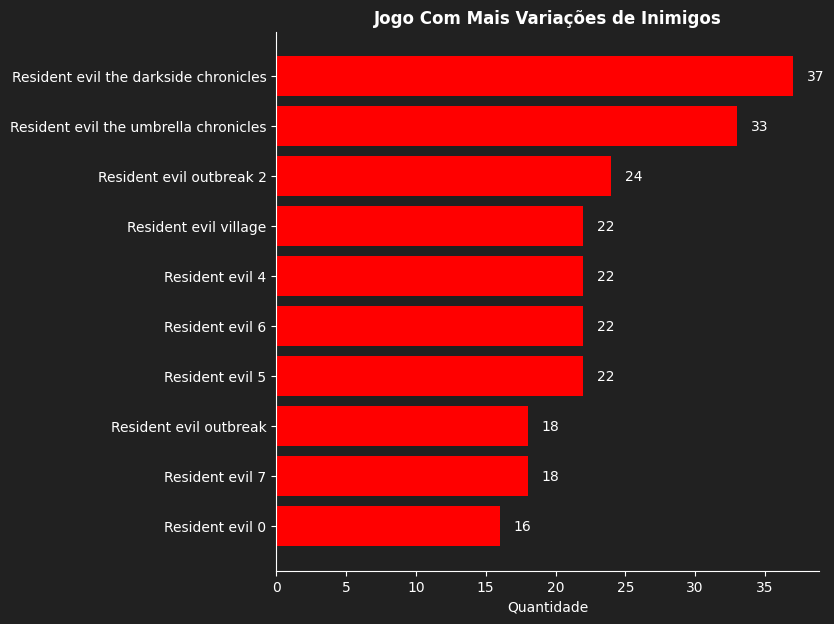

In [5]:
fig, ax = plt.subplots(figsize=(7,7))

barras = ax.barh(
    contagem_jogos.index,
    contagem_jogos,
    color='red'
)

ax.bar_label(barras, color='white', padding=10,)

ax.set_title('Jogo Com Mais Variações de Inimigos', color='white', weight='bold')

ax.set_facecolor('#212121')
fig.set_facecolor('#212121')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

ax.tick_params(axis='x', color='white', labelcolor='white')
ax.tick_params(axis='y',color='white', labelcolor='white')

ax.set_xlabel('Quantidade',color='white')


## Preparando para o ultimo grafico.

- Bem parecido com o anterior, porém agora vou separar os componentes


In [6]:
df_analise = dados.copy()

df_analise['Componentes'] = df_analise['Componentes'].str.split(',')

df_analise = df_analise.explode('Componentes')

df_analise['Componentes']=  df_analise['Componentes'].str.strip()

contagem_componentes = df_analise['Componentes'].value_counts().iloc[:10]

contagem_componentes



Componentes
t-virus       80
plaga         35
mofo          30
c-virus       21
cadou         16
t-abyss       14
uroboros      11
t-veronica     8
t-phobos       8
g-virus        6
Name: count, dtype: int64

## Análise da diversidade de Criaturas por Agente Biológico.
Este gráfico tem como objetivo exibir a representatividade percentual de cada agente biológico no total de criaturas catalogadas. O t-virus mantém sua predominância histórica, possivelmente por ser o patógeno pioneiro e o que passou por mais ciclos de testes e variações laboratoriais ao longo da franquia.

Abaixo dele, destacam-se as Plagas e o Mofo. A introdução da Plaga é um ponto de virada interessante, pois, por se tratar de um parasita, abriu novas possibilidades biológicas e mecânicas de jogo. Em seguida, o Mofo demonstra sua relevância ao apresentar uma alta taxa de variação não apenas em Resident Evil 7, mas também na vasta gama de criaturas encontradas em Resident Evil Village.

Text(0.5, 1.0, 'Diversidade de Criaturas por Agente Biológico')

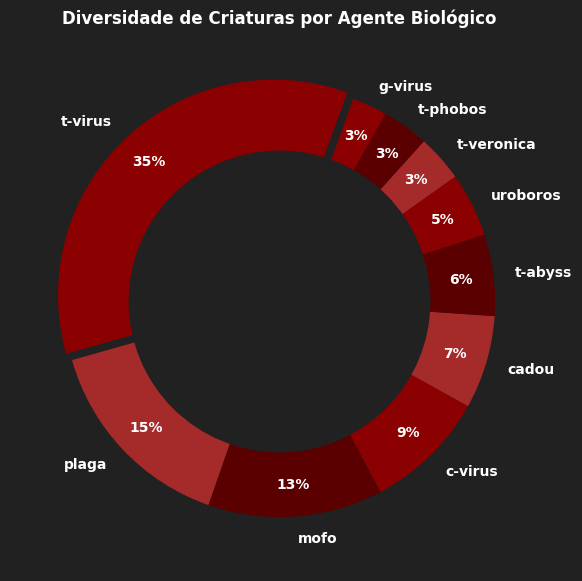

In [7]:
fig, ax = plt.subplots( figsize=(7,7))

ax.pie(
    x=contagem_componentes,
    labels=contagem_componentes.index,
    startangle=70,
    colors=['#8B0000','#A52A2A','#5A0000'],
    autopct="%.0f%%",
    pctdistance=.85,
    textprops={'color':"white",'weight':'bold'},
    explode=(.04,0,0,0,0,0,0,0,0,0)
)

hole = plt.Circle((0, 0), 0.70, fc='#212121')
fig = plt.gcf()

fig.gca().add_artist(hole)

fig.set_facecolor('#212121')

ax.set_title("Diversidade de Criaturas por Agente Biológico", color='white', weight='bold')
